In [1]:
import cptac
import cptac.utils as ut
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import numpy as np

In [2]:
en = cptac.Endometrial()

In [3]:
prot = en.get_proteomics()
g = prot.A1BG
t = g[~g.index.str.endswith(".N")]
n = g[g.index.str.endswith(".N")]
n.index = n.index.str.slice(stop=-2)

In [4]:
diff, p, dist = ut.permutation_test_means(t, n, 10000, True)
print(diff, p)

-1.380356666666667 0.0


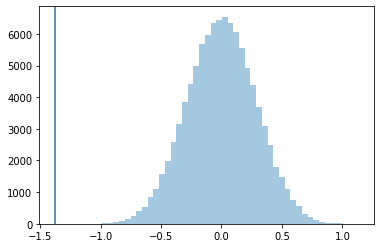

In [5]:
fig, ax = plt.subplots()
sns.distplot(dist, ax=ax, kde=False)
plt.axvline(diff, 0, 4)
plt.show()

In [6]:
diff, p, dist = ut.permutation_test_means(t, n, 100000, False)
print(diff, p)

-1.329369022556391 0.0


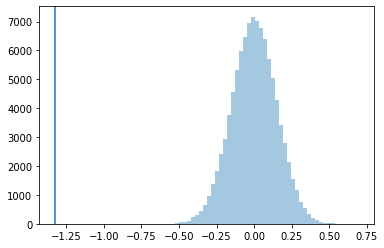

In [7]:
fig, ax = plt.subplots()
sns.distplot(dist, ax=ax, kde=False)
plt.axvline(diff, 0, 4)
plt.show()

In [8]:
ts = t[t.index.isin(n.index)].sort_index()
ns = n[n.index.isin(t.index)].sort_index()
print(np.mean(ts - ns))
scipy.stats.ttest_rel(ts.values, ns.values)

-1.380356666666667


Ttest_relResult(statistic=-10.559601317452033, pvalue=1.8917053714888992e-11)

In [9]:
print(np.mean(t) - np.mean(n))
scipy.stats.ttest_ind(t, n, equal_var=False)

-1.329369022556391


Ttest_indResult(statistic=-13.85026667921029, pvalue=1.8326322517636131e-25)

In [10]:
# Another idea of how to do a paired mean permutation test? But everyone online
# did it by permuting the signs of the paired differences, which amounts to permuting
# the group membership, so I guess that's the better way. Probably has some
# statistical justification.

def perm(a, b, num):
    act = np.mean(a - b)
    g = np.random.RandomState(0)
    
    null = []
    ct = 0
    
    both = a.append(b)
    l = a.size
    
    for i in range(num):
        bothp = g.permutation(both.values)
        ap = bothp[:l]
        bp = bothp[l:]
        pd = np.mean(ap - bp)
        null.append(pd)
        if abs(pd) >= abs(act):
            ct += 1
     
    P = ct / num
    return act, P, null

In [11]:
diff, p, dist = perm(ts, ns, 100000)

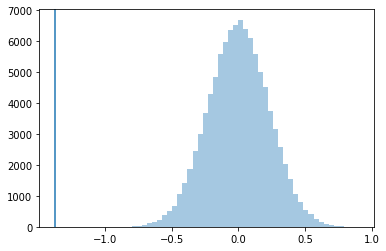

In [12]:
fig, ax = plt.subplots()
sns.distplot(dist, ax=ax, kde=False)
plt.axvline(diff, 0, 4)
plt.show()